<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/415_reglin_4.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

# ✏️ Esercizi

## Preparazione del Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sc
import statistics as st
import arviz as az
import bambi as bmb
import pymc as pm
from pymc import HalfNormal, Model, Normal, sample
import statsmodels.api as sm
import networkx as nx
import graphviz
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=Warning)

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 12345
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

## Inferenza Causale

In questo esercizio genereremo dei dati compatibili con il seguente Grafo Aciclico Diretto (DAG) causale. Per mantenere le cose semplici, tutti i nodi nel grafo hanno una distribuzione normale e le relazioni tra i nodi sono lineari. Un Causal DAG (Grafo Aciclico Diretto) è un grafo aciclico diretto, ovvero un modello grafico utilizzato per rappresentare le relazioni causali tra le variabili. Nel DAG, i nodi rappresentano le variabili e gli archi diretti indicano la direzione della causa-effetto tra le variabili. 

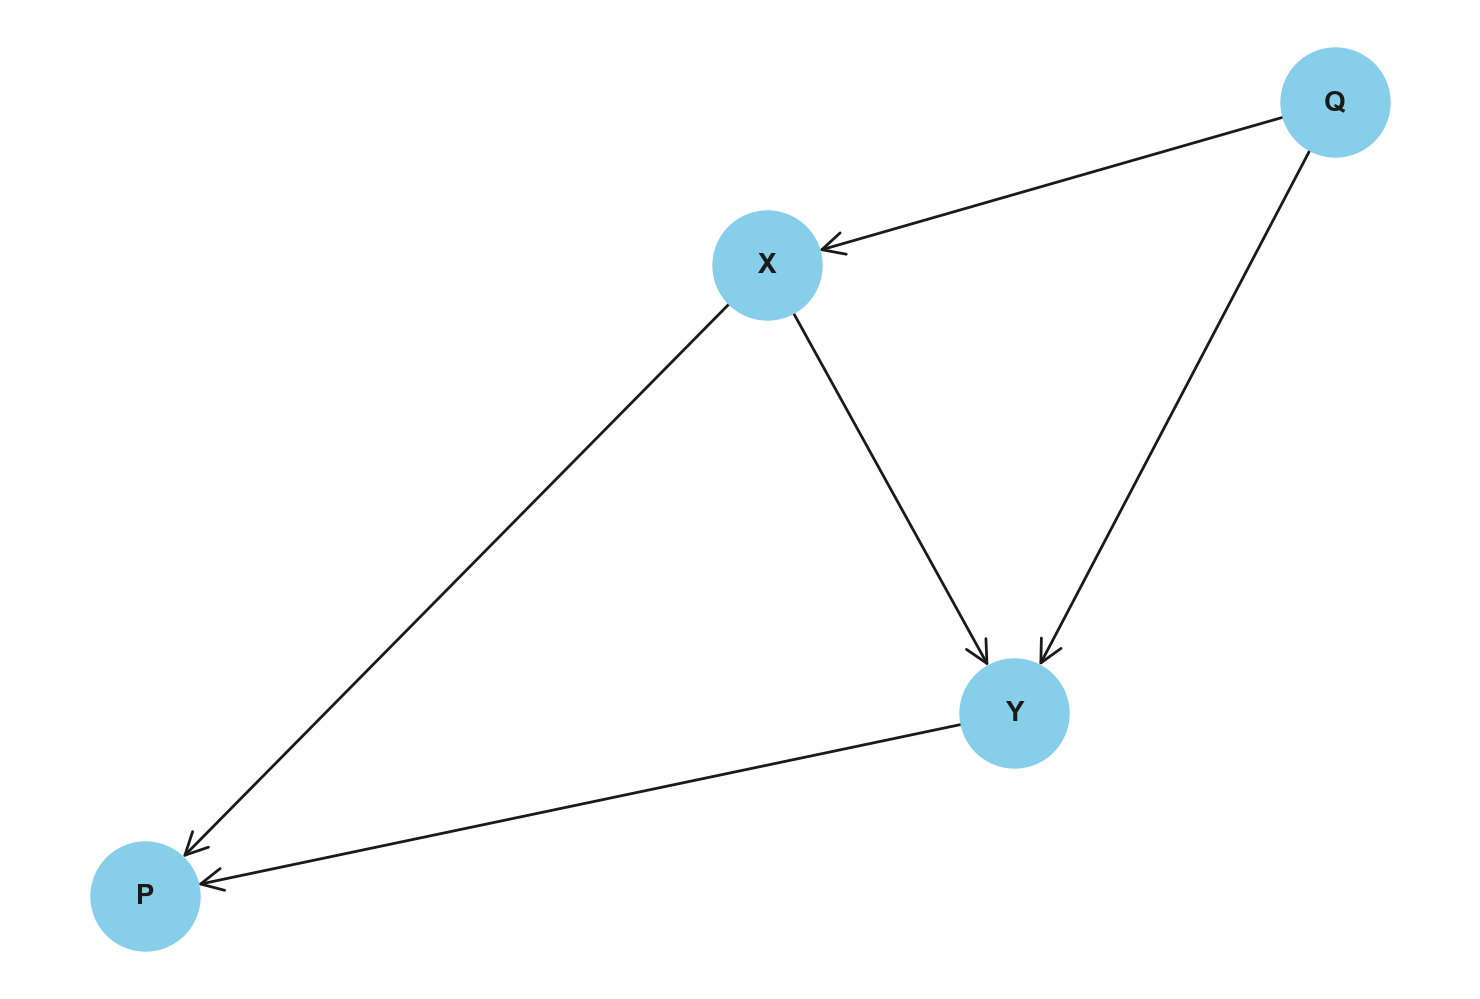

In [3]:
graph = nx.DiGraph()
#graph.add_edges_from([("root", "a"), ("a", "b"), ("a", "e"), ("b", "c"), ("b", "d"), ("d", "e")])
graph.add_edges_from([("X", "Y"), ("X", "P"), ("Y", "P"), ("Q", "X"), ("Q", "Y")])

# Draw the graph
pos = nx.spring_layout(graph, seed=42)  # Position nodes using spring layout algorithm
nx.draw(graph, pos, with_labels=True, node_size=1500, node_color="skyblue", font_size=10, font_weight="bold", arrowsize=20, arrowstyle="->")
plt.show()

Siamo principalmente interessati alla relazione tra due variabili, chiamate X e Y. Tuttavia, dobbiamo considerare la presenza di una variabile confondente, indicata come Q, che ha un'influenza sia su X che su Y. Inoltre, il DAG introduce un altro concetto, chiamato collider, rappresentato da P, che è una variabile influenzata sia da X che da Y. In sintesi, nella nostra analisi dobbiamo prendere in considerazione la presenza di queste variabili confondenti e collider, poiché possono influenzare i risultati e complicare la comprensione della relazione tra X e Y.

Generiamo un dataset simulato di 5000 osservazioni e osserviamo le prime 5. 

In [4]:
N = 5_000
Q = rng.normal(size=N)
X = rng.normal(loc=0.14*Q, scale=0.4, size=N)
Y = rng.normal(loc=0.7*X + 0.11*Q, scale=0.24, size=N)
P = rng.normal(loc=0.43*X + 0.21*Y, scale=0.22, size=N)
df = pd.DataFrame({"Q": Q, "X": X, "Y": Y, "P": P})

df.head()

,Q,X,Y,P
0,-1.423825,-0.421305,-0.498653,0.039523
1,1.263728,0.518683,0.576752,0.059713
2,-0.870662,0.354544,0.157422,0.367875
3,-0.259173,0.135539,0.307791,0.016444
4,-0.075343,-0.048982,0.114759,0.134512


Si noti che abbiamo specificato un vero effetto causale tra X e Y pari a 0.7. Di seguito vedremo quanto accuratamente possiamo recuperare questo valore utilizzando diverse approcci.

## Approccio 1

Ciò che ci interessa è la relazione tra X e Y. Anche se può sembrare una semplificazione, è abbastanza comune stimare direttamente questa relazione. Possiamo costruire un modello per fare questo utilizzando `bambi`` (Capretto et al. 2022) con la nota notazione delle formule, Y ~ X (Wilkinson e Rogers 1973).

In [5]:
model = bmb.Model("Y ~ X", df)
results = model.fit(method="nuts_numpyro", idata_kwargs={"log_likelihood": True})

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

...

Running chain 1:  85%|████████████████████████████████████████▊       | 1700/2000 [00:02<00:00, 4964.42it/s]

Running chain 0: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 797.72it/s]


Running chain 1: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 798.37it/s]


Running chain 2: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 799.12it/s]


Running chain 3: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 799.68it/s]

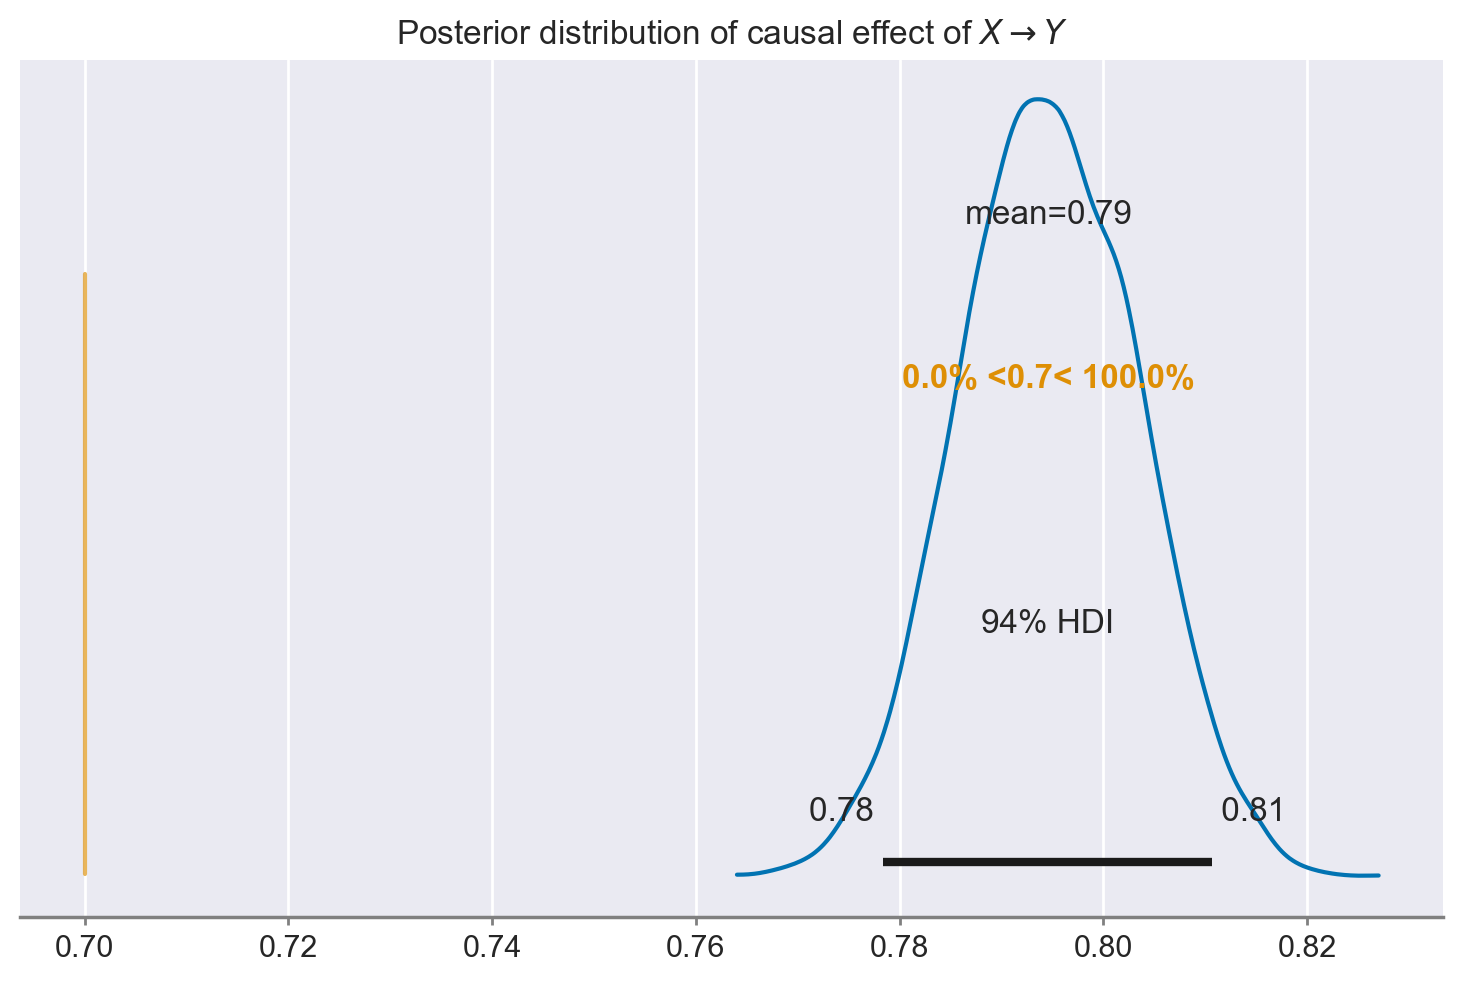

In [6]:
ax = az.plot_posterior(results.posterior["X"], ref_val=0.7)
ax.set_title(r"Posterior distribution of causal effect of $X \rightarrow Y$");

Notiamo che la nostra stima dell'influenza causale di X sulla Y è molto distante dal valore reale. Ciò non sorprenderà gran parte delle persone con una formazione statistica, poiché non abbiamo considerato nessuna delle altre variabili presenti nel nostro dataset.

## Approccio 2

Quindi proviamo a correggere questa situazione. Questa volta includeremo tutte le variabili nel modello di regressione. Questo è un approccio molto comune ed è stato chiamato "l'insalata causale" (vedi McElreath 2020; anche Bulbulia et al. 2021). L'idea alla base è che, includendo tutte le variabili nel modello di regressione, possiamo osservare l'effetto di X su Y dopo aver tenuto conto di tutte le altre variabili. Sembra ragionevole. Vediamo ora quanto bene funziona questo approccio nel caso presente.

In [7]:
model = bmb.Model("Y ~ Q + X + P", df)
results = model.fit(method="nuts_numpyro", idata_kwargs={"log_likelihood": True})

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

...

Running chain 0: 100%|████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 3638.90it/s]

Running chain 0: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 674.66it/s]


Running chain 1: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 674.98it/s]


Running chain 2: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 675.40it/s]


Running chain 3: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 675.77it/s]

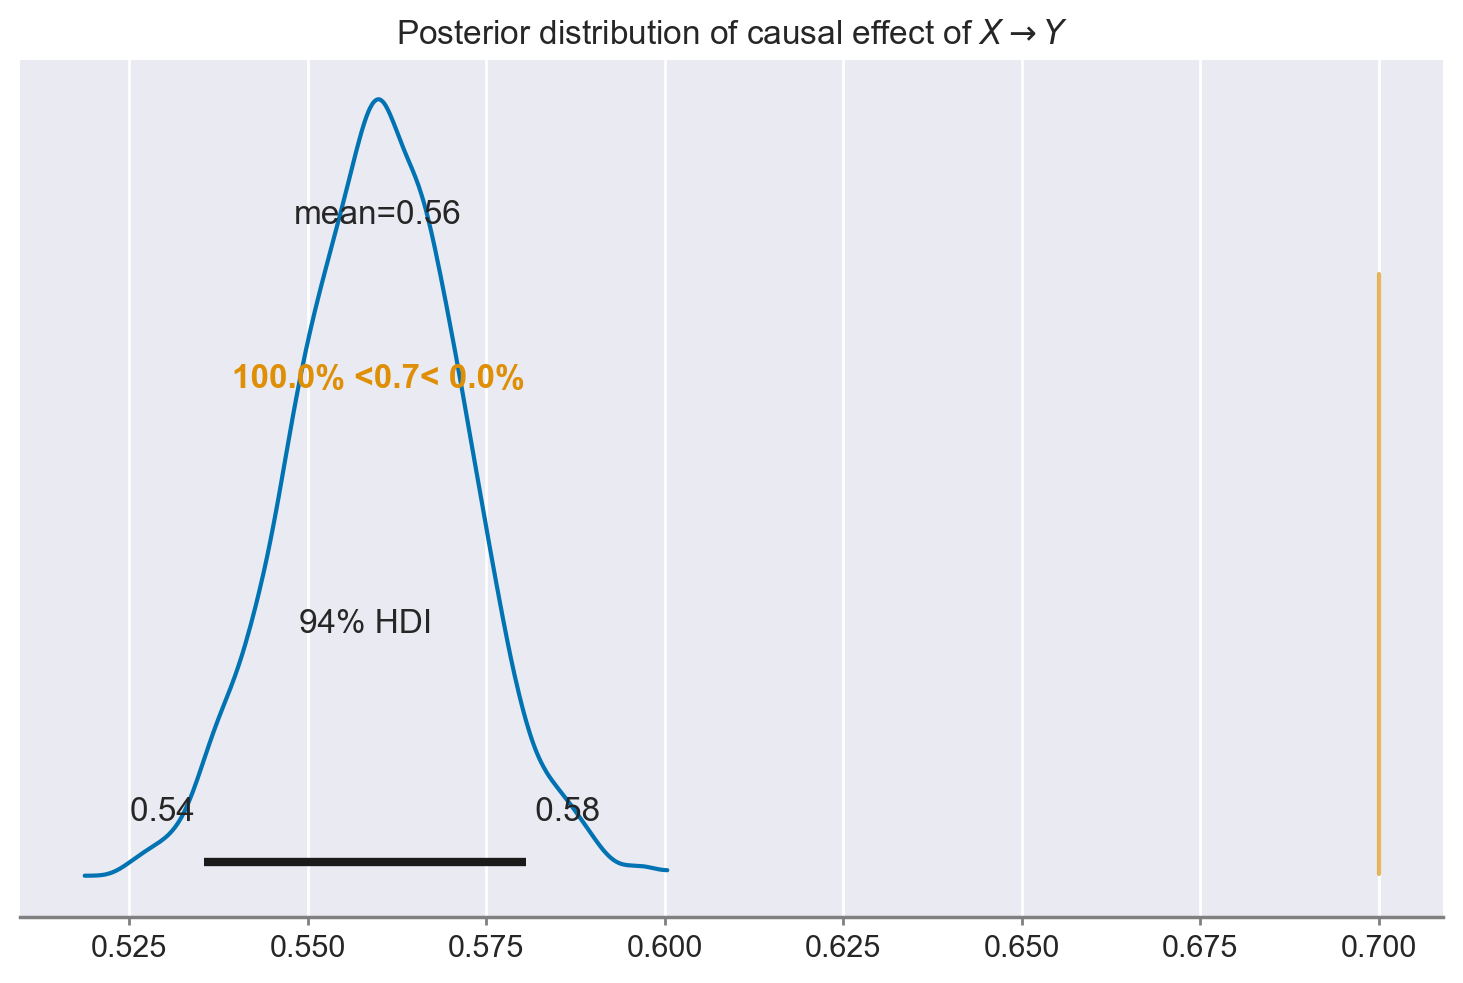

In [8]:
ax = az.plot_posterior(results.posterior["X"], ref_val=0.7)
ax.set_title(r"Posterior distribution of causal effect of $X \rightarrow Y$");

Questo è persino peggio rispetto a prima. Cosa sta succedendo? Il problema è che abbiamo incluso sia controlli validi che controlli non validi nella nostra regressione. Ma come si possono distinguere i controlli validi da quelli non validi?

## Approccio 3: solo controlli validi

Una risposta alla domanda precedente che si applica al caso presente è che, riguardo al DAG presentato in precedenza, si configura una via backdoor tra X e Y attraverso Q. Ciò implica che esiste un percorso statistico in cui X può influenzare Y tramite Q. Quando si ha una via backdoor, è necessario bloccarla. Ciò può essere realizzato includendo Q nella nostra regressione. In questo modo, Q diventa un buon controllo capace di mitigare gli effetti confondenti di Q e ottenere stime più accurate dell'influenza di X su Y.

In [9]:
model = bmb.Model("Y ~ X + Q", df)
results = model.fit(method="nuts_numpyro", idata_kwargs={"log_likelihood": True})

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

...

Running chain 0:  90%|███████████████████████████████████████████▏    | 1800/2000 [00:02<00:00, 4082.23it/s]

Running chain 0: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 721.21it/s]


Running chain 1: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 721.73it/s]


Running chain 2: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 722.26it/s]


Running chain 3: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 722.73it/s]

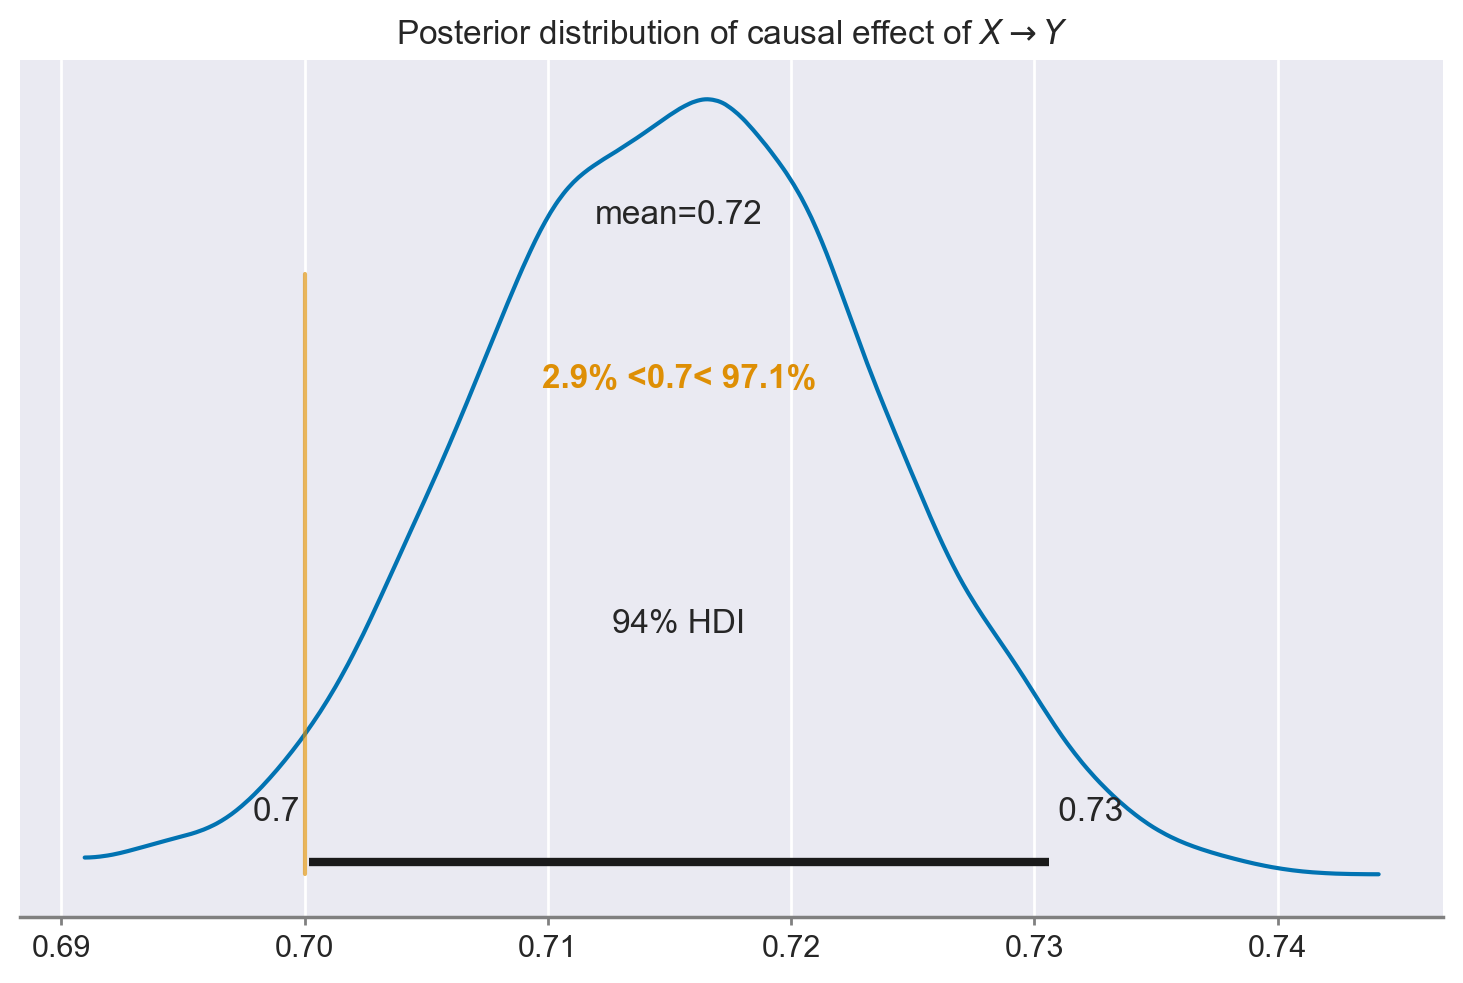

In [10]:
ax = az.plot_posterior(results.posterior["X"], ref_val=0.7)
ax.set_title(r"Posterior distribution of causal effect of $X \rightarrow Y$");

Abbiamo recuperato il vero effetto causale di X. Abbiamo ottenuto questo risultato includendo solo i "buoni" controlli nel modello di regressione.

## Approccio del Modello Causale Strutturale Bayesiano

In alternativa, è possibile specificare tutta la struttura causale descritta dal DAG in un modello bayesiano.

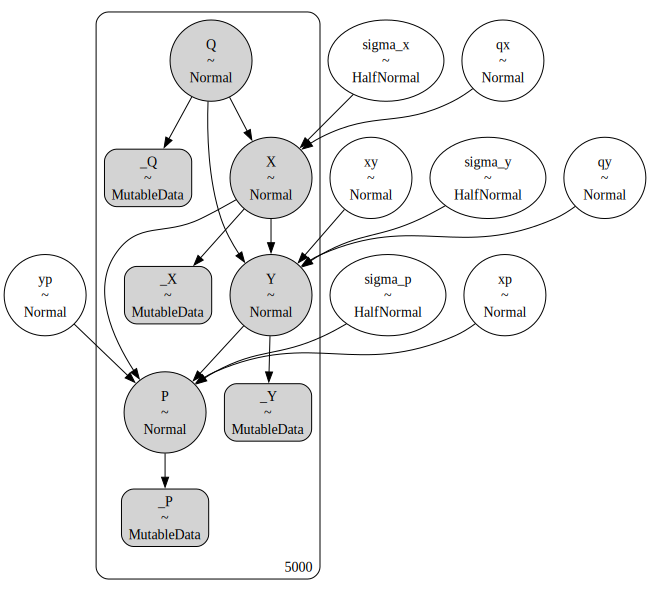

In [11]:
with pm.Model() as model:
    # data
    _Q = pm.MutableData("_Q", df["Q"])
    _X = pm.MutableData("_X", df["X"])
    _Y = pm.MutableData("_Y", df["Y"])
    _P = pm.MutableData("_P", df["P"])

    # priors on slopes
    # x ~ q
    qx = pm.Normal("qx")
    # y ~ x + q
    xy = pm.Normal("xy")
    qy = pm.Normal("qy")
    # p ~ x + y
    xp = pm.Normal("xp")
    yp = pm.Normal("yp")

    # priors on sd's
    sigma_x = pm.HalfNormal("sigma_x")
    sigma_y = pm.HalfNormal("sigma_y")
    sigma_p = pm.HalfNormal("sigma_p")
    
    # model
    Q = pm.Normal("Q", observed=_Q)
    X = pm.Normal("X", mu=qx*Q, sigma=sigma_x, observed=_X)
    Y = pm.Normal("Y", mu=xy*X + qy*Q, sigma=sigma_y, observed=_Y)
    P = pm.Normal("P", mu=xp*X + yp*Y, sigma=sigma_p, observed=_P)

pm.model_to_graphviz(model)

In [12]:
with model:
    idata = pm.sampling_jax.sample_numpyro_nuts(idata_kwargs={"log_likelihood": True})

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

...

Running chain 0: 100%|█████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 805.59it/s]

Running chain 0: 100%|█████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 369.68it/s]


Running chain 1: 100%|█████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 369.77it/s]


Running chain 2: 100%|█████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 369.90it/s]


Running chain 3: 100%|█████████████████████████████████████████████████| 2000/2000 [00:05<00:00, 370.02it/s]

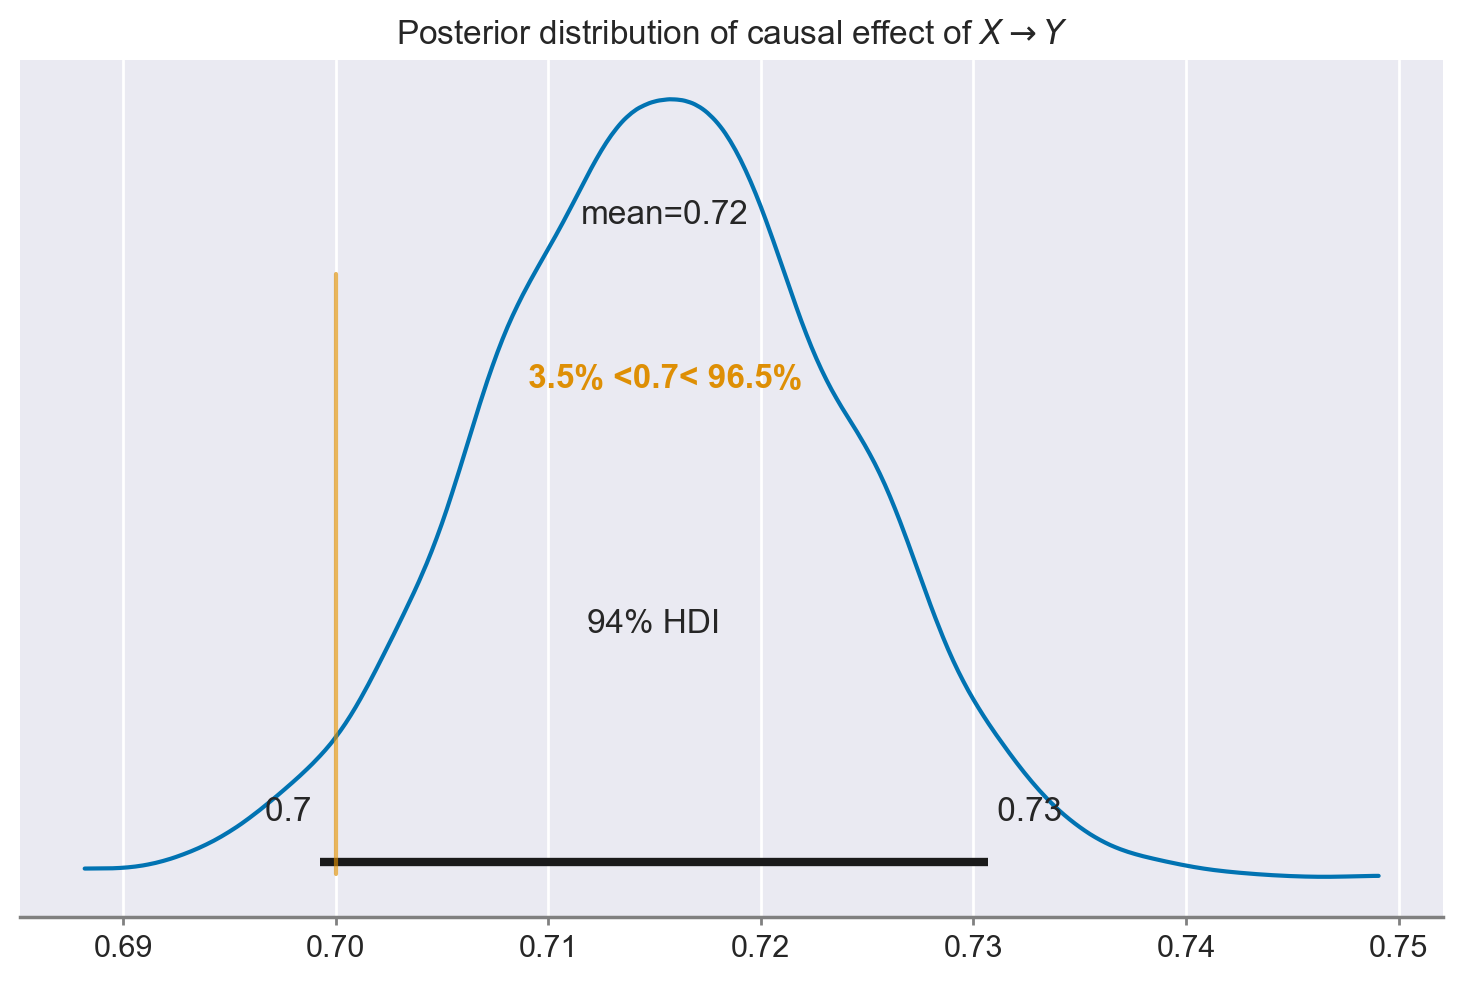

In [13]:
ax = az.plot_posterior(idata, var_names="xy", ref_val=0.7)
ax.set_title(r"Posterior distribution of causal effect of $X \rightarrow Y$");

In questa situazione, siamo riusciti a recuperare il vero effetto causale di X, ma questa volta non abbiamo dovuto preoccuparci dei controlli buoni e cattivi. Abbiamo semplicemente specificato il DAG e lasciato che l'approccio di modellazione causale bayesiana facesse il resto.

## Conlusioni

In linea con quanto discusso nel capitolo sull'inferenza causale, possiamo concludere che l'approccio di semplicemente inserire tutte le variabili in un modello di regressione, sperando che questo funzioni in modo ottimale, risulta essere insufficiente. Al contrario, è essenziale condurre un'analisi approfondita delle relazioni causali tra le variabili coinvolte e includere i controlli in modo accurato. Anche nell'esempio presente, l'inclusione inappropriata dei controlli ha portato a risultati fuorvianti. Per garantire la validità delle nostre analisi, è fondamentale valutare attentamente quali variabili includere come controlli al fine di evitare distorsioni nei risultati.

In [14]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Thu Mar 28 2024

Python implementation: CPython
Python version       : 3.11.8
IPython version      : 8.22.2

pymc       : 5.11.0
bambi      : 0.13.0
matplotlib : 3.8.3
statsmodels: 0.14.1
scipy      : 1.12.0
pandas     : 2.2.1
networkx   : 3.2.1
graphviz   : 0.20.3
seaborn    : 0.13.2
arviz      : 0.17.1
numpy      : 1.26.4

Watermark: 2.4.3

